# External Quantum Efficiency (EQE) of Solar Cells

This notebook explains the working principle of External Quantum Efficiency
(EQE) measurements of solar cells, and shows how to model and interpret
EQE data using simplified physical models.

EQE quantifies how efficiently a solar cell converts incident photons of a
given wavelength into collected charge carriers. From EQE (and the related
spectral responsivity), we can extract:
- absorption behaviour of the absorber material,
- carrier collection properties (diffusion length, surface recombination),
- the short-circuit current density, $J_{sc}$,
- optical losses (reflection, parasitic absorption).

<div align="center">
   <img src="./figures/fig_cell_structure.jpg" width="600">
</div>

*Figure placeholder: cross-section of a typical crystalline silicon solar
cell (e.g. Al-BSF vs. PERC), showing emitter, base, and rear structure.*

All functions used in this notebook are implemented in
[`eqe_helper.py`](./eqe_helper.py) so that the notebook itself stays short.

In [1]:
# --- Google Colab setup -------------------------------------------------
# Colab opens this notebook file on its own, without the rest of the
# repository, so eqe_helper.py and figures/ would be missing. This cell
# clones the repo and switches into the EQE folder when (and only when)
# running on Colab. It does nothing when you run the notebook locally.
import os
import sys
import subprocess

if "google.colab" in sys.modules and not os.path.exists("eqe_helper.py"):
    REPO_URL = "https://github.com/YOUR_GH_USERNAME/semicon_characterisation.git"
    subprocess.run(["git", "clone", "-q", REPO_URL, "/content/semicon"], check=True)
    os.chdir("/content/semicon/EQE")
    print("Colab setup complete, working directory:", os.getcwd())

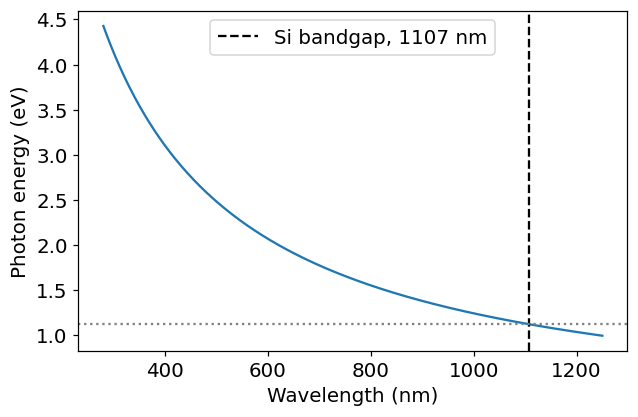

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import eqe_helper as eh

plt.rcParams.update({'font.size': 13})

wavelength_nm = np.linspace(280, 1250, 400)
E_photon = eh.photon_energy_eV(wavelength_nm)

plt.figure(figsize=(6, 4))
plt.plot(wavelength_nm, E_photon)
plt.axvline(eh.LAMBDA_G_NM, ls='--', color='k', label=f'Si bandgap, {eh.LAMBDA_G_NM:.0f} nm')
plt.axhline(eh.EG_SI_EV, ls=':', color='gray')
plt.xlabel('Wavelength (nm)'); plt.ylabel('Photon energy (eV)')
plt.legend(); plt.tight_layout(); plt.show()

## Photon energy and the relevant wavelength range

The energy of a photon is
$$
E_{\text{phot}}(\lambda) = \frac{hc}{\lambda}
$$
where $h$ is Planck's constant and $c$ is the speed of light.

Silicon has an (indirect) bandgap of $E_g = 1.12\ \text{eV}$, corresponding
to a wavelength of about $1107\ \text{nm}$ (the *absorption edge*). Photons
with $\lambda$ above this edge do not have enough energy to generate an
electron-hole pair in silicon, so the relevant wavelength range for a
silicon solar cell is roughly $300$-$1200\ \text{nm}$.

## Absorption of light: the Lambert-Beer law

Light intensity decays exponentially with depth $z$ into the semiconductor:
$$
\Phi(\lambda, z) = \Phi_0(\lambda)\, \exp\!\big(-\alpha(\lambda)\, z\big)
$$
where $\Phi_0$ is the incident photon flux and $\alpha(\lambda)$ is the
**absorption coefficient**. A convenient related quantity is the
**absorption length**,
$$
L_\alpha(\lambda) = \frac{1}{\alpha(\lambda)},
$$
the depth at which the intensity has dropped to $1/e \approx 37\%$ of its
initial value.

Silicon is an *indirect* semiconductor: absorption near the bandgap
requires phonon assistance, so $\alpha(\lambda)$ falls off gradually (over
several hundred nm) rather than sharply at $E_g$, unlike a direct-gap
material. This is why $\alpha(\lambda)$ varies by six orders of magnitude
across the useful wavelength range.

At 300 nm: L_alpha = 10.0 nm  (absorbed near the surface)
At 1100 nm: L_alpha = 1.67 mm (weakly absorbed, penetrates deep)


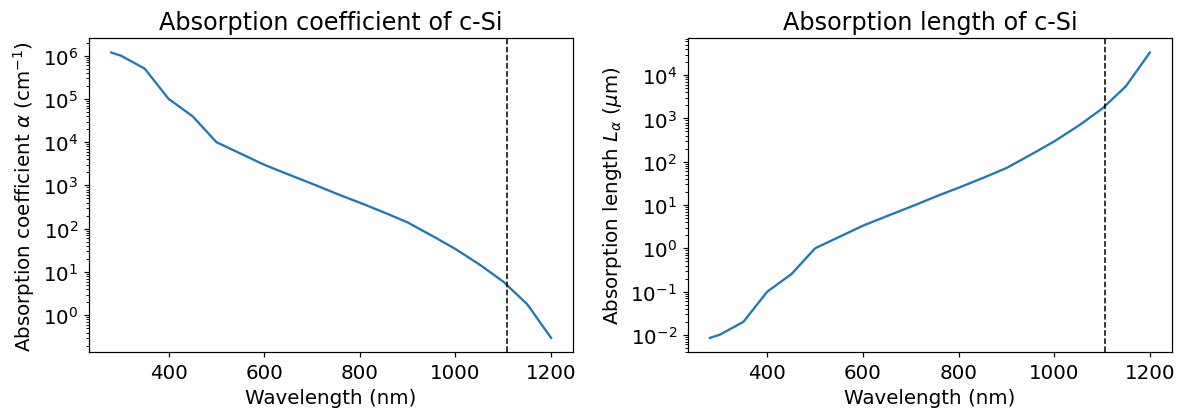

In [3]:
wl = np.linspace(280, 1200, 400)
alpha = eh.alpha_silicon(wl)          # 1/cm
L_alpha = eh.absorption_length_um(wl)  # um

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].semilogy(wl, alpha)
axes[0].axvline(eh.LAMBDA_G_NM, ls='--', color='k', lw=1)
axes[0].set_xlabel('Wavelength (nm)'); axes[0].set_ylabel(r'Absorption coefficient $\alpha$ (cm$^{-1}$)')
axes[0].set_title('Absorption coefficient of c-Si')

axes[1].semilogy(wl, L_alpha)
axes[1].axvline(eh.LAMBDA_G_NM, ls='--', color='k', lw=1)
axes[1].set_xlabel('Wavelength (nm)'); axes[1].set_ylabel(r'Absorption length $L_\alpha$ ($\mu$m)')
axes[1].set_title('Absorption length of c-Si')

plt.tight_layout(); plt.show()

print(f"At 300 nm: L_alpha = {eh.absorption_length_um(300)*1e3:.1f} nm  (absorbed near the surface)")
print(f"At 1100 nm: L_alpha = {eh.absorption_length_um(1100)/1e3:.2f} mm (weakly absorbed, penetrates deep)")

**Interpretation**: at short wavelengths (UV/blue), light is absorbed within
tens of nanometres of the surface — generation happens right at the front
of the cell, where recombination losses (surface, emitter) matter most. At
long wavelengths (near-IR), the absorption length approaches or exceeds the
cell thickness ($\sim 160\ \mu\text{m}$ for a wafer-based cell) — light must
travel deep into (and can be reflected within) the device before being
absorbed, so bulk and rear-surface properties dominate.

## Carrier generation and collection

Each absorbed photon (to first order) generates one electron-hole pair. The
volumetric generation rate follows directly from the Lambert-Beer law:
$$
g(\lambda, z) = -\frac{d\Phi}{dz} = (1-R)\,\Phi_0(\lambda)\,\alpha(\lambda)\, e^{-\alpha(\lambda) z}
$$
where $R$ is the reflectance of the cell.

Not every generated carrier is collected: minority carriers must **diffuse**
to a selective contact before they **recombine**. The probability that a
carrier generated at depth $z$ is collected is the **collection efficiency**
$\eta_c(z)$. For the base region of a solar cell (thickness $W$, diffusion
length $L$, rear surface recombination velocity $S$):
$$
\eta_c(z) = \cosh\!\left(\frac{z}{L}\right) - \frac{L}{L_{\text{eff}}}\sinh\!\left(\frac{z}{L}\right),
\qquad
L_{\text{eff}} = L\,\frac{S\sinh(W/L) + D\cosh(W/L)}{S\cosh(W/L) + D\sinh(W/L)}
$$
with $D$ the minority-carrier diffusion constant. A **longer diffusion
length** and a **lower surface recombination velocity** both increase
$\eta_c$, especially deep in the cell.

<div align="center">
   <img src="./figures/fig_collection_efficiency.jpg" width="500">
</div>

*Figure placeholder: sketch of the collection-efficiency profile
$\eta_c(z)$ across the cell thickness, analogous to Fig. 4 of the lab
manual (Schinke et al.).*

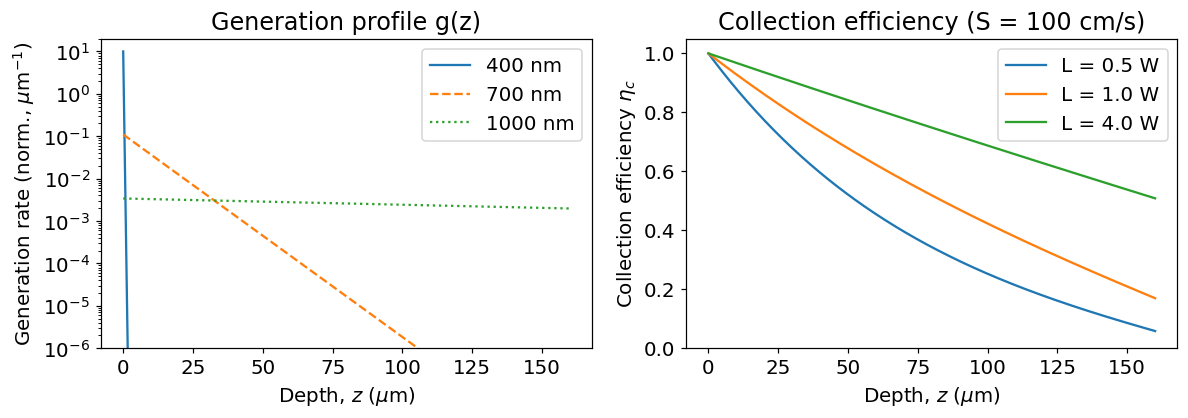

In [4]:
z = np.linspace(0, 160, 300)  # depth, um
W = 160.0  # base thickness, um

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Generation profiles at a few wavelengths (log scale: decay lengths span
# several orders of magnitude, from ~0.1 um at 400 nm to ~mm at 1000 nm)
for wl_i, style in zip([400, 700, 1000], ['-', '--', ':']):
    g = eh.generation_profile(z, wl_i)
    axes[0].semilogy(z, g, style, label=f'{wl_i} nm')
axes[0].set_xlabel(r'Depth, $z$ ($\mu$m)'); axes[0].set_ylabel(r'Generation rate (norm., $\mu$m$^{-1}$)')
axes[0].set_title('Generation profile g(z)')
axes[0].set_ylim(1e-6, 20)
axes[0].legend()

# Collection efficiency for a few diffusion lengths (cf. Fig. 4 of lab manual)
for L_i in [0.5*W, 1.0*W, 4.0*W]:
    eta_c = eh.collection_efficiency(z, L_um=L_i, W_um=W, S_cm_s=100.0)
    axes[1].plot(z, eta_c, label=f'L = {L_i/W:.1f} W')
axes[1].set_xlabel(r'Depth, $z$ ($\mu$m)'); axes[1].set_ylabel(r'Collection efficiency $\eta_c$')
axes[1].set_title('Collection efficiency (S = 100 cm/s)')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.tight_layout(); plt.show()

## Short-circuit current and the external quantum efficiency

Combining generation and collection, and integrating over the cell
thickness, gives the short-circuit current density:
$$
j_{sc} = q \int d\lambda \int_0^{W} dz\; g_0(\lambda,z)\,\eta_c(z)
       = q \int d\lambda\; \Phi_0(\lambda)\, \text{EQE}(\lambda)
$$
where the **external quantum efficiency** is defined as
$$
\text{EQE}(\lambda) = \int_0^{W} dz\; g(\lambda,z)\,\eta_c(z) \Big/ \Phi_0(\lambda)
                     = (1-R(\lambda))\int_0^{W} \alpha(\lambda)\, e^{-\alpha(\lambda)z}\,\eta_c(z)\, dz
$$
EQE is dimensionless: it is the ratio of collected electrons to incident
photons at each wavelength. Equivalently, using the internal quantum
efficiency IQE (collected electrons per *absorbed* photon):
$$
\text{EQE}(\lambda) = T_{\text{ext}}(\lambda)\cdot \text{IQE}(\lambda), \qquad
T_{\text{ext}} = 1 - R_{\text{ext}} - A_{\text{ext}}
$$
i.e. EQE = (fraction of light that enters the cell) $\times$ (fraction of
that light converted into collected carriers).

Jsc (300-1200 nm band) = 27.43 mA/cm^2


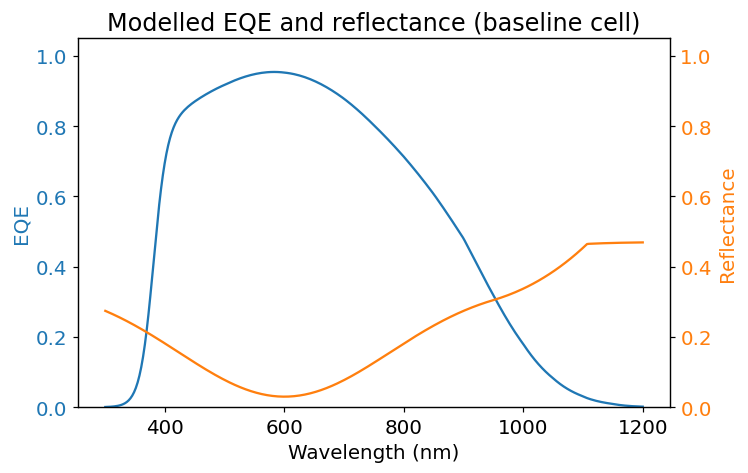

In [5]:
wl = np.linspace(300, 1200, 300)

eqe = eh.eqe_spectrum(wl, W_um=160.0, L_um=250.0, S_cm_s=100.0)
R = eh.arc_reflectance(wl)

fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.plot(wl, eqe, color='C0', label='EQE')
ax1.set_xlabel('Wavelength (nm)'); ax1.set_ylabel('EQE', color='C0')
ax1.set_ylim(0, 1.05)
ax1.tick_params(axis='y', labelcolor='C0')

ax2 = ax1.twinx()
ax2.plot(wl, R, color='C1', label='Reflectance')
ax2.set_ylabel('Reflectance', color='C1')
ax2.set_ylim(0, 1.05)
ax2.tick_params(axis='y', labelcolor='C1')

plt.title('Modelled EQE and reflectance (baseline cell)')
fig.tight_layout(); plt.show()

jsc = eh.jsc_from_eqe(wl, eqe)
print(f"Jsc (300-1200 nm band) = {jsc:.2f} mA/cm^2")

**Interpretation** (compare with Fig. 5 of the lab manual): near 300 nm,
almost all light is absorbed within the anti-reflection coating (ARC) and
emitter, where recombination is high, so EQE is low. EQE rises toward
unity around 500-600 nm, where reflection is minimal (ARC minimum) and
light is absorbed mainly in the base, where collection is efficient. Above
$\sim$600 nm, EQE decreases slowly as reflectance increases; above
$\sim$1000 nm, EQE drops steeply because absorption becomes weak and a
growing fraction of carriers are generated too deep (or too close to the
rear surface) to be collected.

## Front vs. rear: what changes the EQE shape

- **Short wavelengths** (300-500 nm): sensitive to the front surface / ARC
  quality and emitter recombination — governs the *blue response*.
- **Long wavelengths** (900-1200 nm): sensitive to the bulk diffusion
  length $L$ and rear surface recombination velocity $S$ (and rear
  reflectance / light trapping) — governs the *red / near-IR response*.

This is why, for example, a PERC cell (dielectric rear passivation, low
$S$, better rear reflector) typically shows a **higher near-IR EQE** than
a comparable Al-BSF cell (metallized rear, higher $S$).

<div align="center">
   <img src="./figures/fig_albsf_vs_perc.jpg" width="600">
</div>

*Figure placeholder: Al-BSF vs. PERC cell structures side-by-side,
highlighting the rear-side difference responsible for the near-IR EQE gap.*

Jsc Al-BSF-like: 26.37 mA/cm^2
Jsc PERC-like:   28.37 mA/cm^2


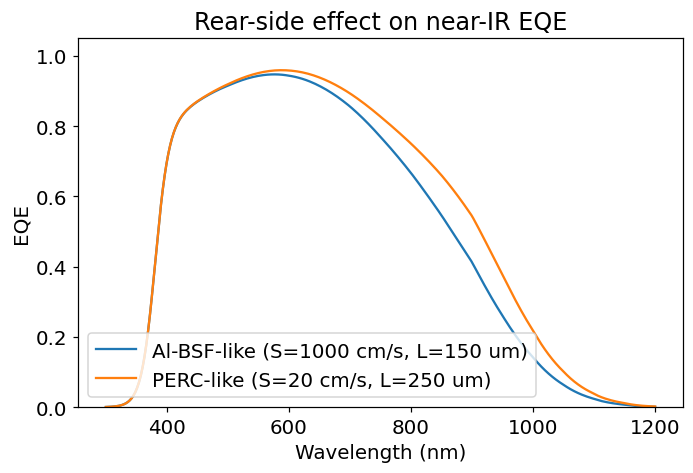

In [6]:
wl = np.linspace(300, 1200, 300)

# "Al-BSF-like": shorter effective diffusion length, high rear S (metallized rear)
eqe_albsf = eh.eqe_spectrum(wl, W_um=160, L_um=150, S_cm_s=1000.0)
# "PERC-like": longer diffusion length, low rear S (dielectric passivation)
eqe_perc  = eh.eqe_spectrum(wl, W_um=160, L_um=250, S_cm_s=20.0)

plt.figure(figsize=(6.5, 4.5))
plt.plot(wl, eqe_albsf, label='Al-BSF-like (S=1000 cm/s, L=150 um)')
plt.plot(wl, eqe_perc, label='PERC-like (S=20 cm/s, L=250 um)')
plt.xlabel('Wavelength (nm)'); plt.ylabel('EQE')
plt.ylim(0, 1.05); plt.legend(); plt.title('Rear-side effect on near-IR EQE')
plt.tight_layout(); plt.show()

print(f"Jsc Al-BSF-like: {eh.jsc_from_eqe(wl, eqe_albsf):.2f} mA/cm^2")
print(f"Jsc PERC-like:   {eh.jsc_from_eqe(wl, eqe_perc):.2f} mA/cm^2")

## Measuring EQE: spectral responsivity

EQE cannot be measured directly. Instead, the **spectral responsivity**
$s(\lambda)$ — the ratio of generated photocurrent density to incident
irradiance — is measured, and EQE is calculated from it:
$$
s(\lambda) = \frac{j_{sc}(\lambda)}{\Phi_0(\lambda)\, q}\;\;\text{[not used directly]}
\qquad\Longrightarrow\qquad
\text{EQE}(\lambda) = s(\lambda)\,\frac{hc}{q\lambda}
$$
i.e. $s(\lambda) = \text{EQE}(\lambda)\cdot q\lambda / hc$, with units of
A/W.

**Differential measurement.** Because a solar cell's response can depend on
its operating point (injection level), the standard measures a
*differential* spectral responsivity (DSR): the cell is illuminated with
steady white **bias light** (setting realistic injection conditions), plus
a small amount of chopped, **monochromatic** light of wavelength $\lambda$;
a lock-in amplifier extracts the resulting small AC photocurrent
$\Delta j_{sc}$:
$$
\tilde s(\lambda, E_{\text{bias}}) = \frac{\Delta j_{sc}(\lambda)}{\Delta E_\lambda(\lambda)}
$$
A **reference cell** with known DSR is used to calibrate the absolute scale
of $\Delta E_\lambda$ (the setup's own conversion factors otherwise cancel
only in a *relative* sense).

<div align="center">
   <img src="./figures/fig_measurement_setup.jpg" width="600">
</div>

*Figure placeholder: schematic of the DSR measurement setup (bias lamp,
monochromator + chopper, lock-in amplifier, reference/test cell), cf.
Fig. 7 of the lab manual.*

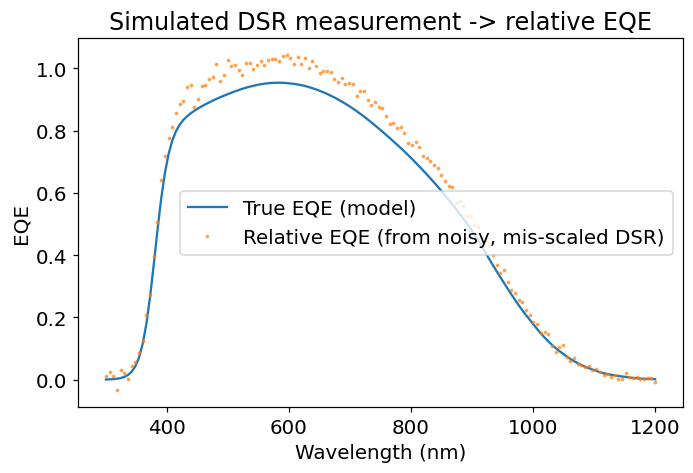

In [7]:
wl = np.linspace(300, 1200, 150)
eqe_true = eh.eqe_spectrum(wl, W_um=160, L_um=250, S_cm_s=100.0)

# "True" responsivity
s_true = eh.responsivity_from_eqe(wl, eqe_true)

# Simulate a real DSR measurement: noise + an unknown calibration scale
# factor (C_ref/C_test in Eq. 22-25 of the lab manual)
s_measured = eh.synthetic_dsr_measurement(
    wl, eqe_true, noise_level=0.015, calibration_scale=1.08, random_state=1
)

# Recover a *relative* EQE from the raw measured responsivity
eqe_relative = eh.eqe_from_responsivity(wl, s_measured)

plt.figure(figsize=(6.5, 4.5))
plt.plot(wl, eqe_true, label='True EQE (model)')
plt.plot(wl, eqe_relative, '.', ms=3, alpha=0.6, label='Relative EQE (from noisy, mis-scaled DSR)')
plt.xlabel('Wavelength (nm)'); plt.ylabel('EQE')
plt.legend(); plt.title('Simulated DSR measurement -> relative EQE')
plt.tight_layout(); plt.show()

## Absolute scaling of the EQE

The EQE obtained directly from the DSR measurement is only **relative**: it
still contains the unknown ratio of calibration factors
$C_{\text{ref}}/C_{\text{test}}$. To obtain the **absolute** EQE, the
relative EQE is scaled so that the $J_{sc}$ calculated from it (Eq. 16-17)
matches a $J_{sc}$ measured independently (e.g. with a sun simulator under
AM1.5G):
$$
f_{sc} = \frac{j_{sc,\text{exp}}}{j_{sc,\text{calc}}}, \qquad
\text{EQE}_{\text{abs}}(\lambda) = f_{sc}\cdot \text{EQE}_{\text{rel}}(\lambda)
$$

f_sc = 1.030


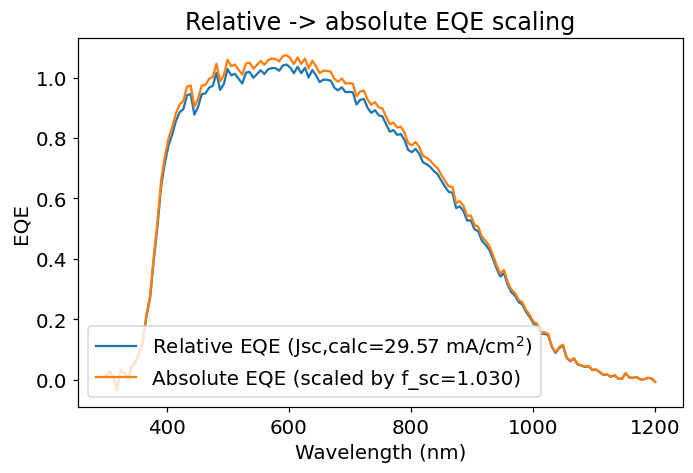

In [8]:
jsc_calc = eh.jsc_from_eqe(wl, eqe_relative)
# Hypothetical sun-simulator measurement: a realistic calibration mismatch
# is a few percent, not tens of percent (a large f_sc usually signals a
# measurement problem, e.g. wrong reference cell or bad alignment).
jsc_exp = jsc_calc * 1.03

f_sc = jsc_exp / jsc_calc
eqe_absolute = f_sc * eqe_relative

plt.figure(figsize=(6.5, 4.5))
plt.plot(wl, eqe_relative, label=f'Relative EQE (Jsc,calc={jsc_calc:.2f} mA/cm$^2$)')
plt.plot(wl, eqe_absolute, label=f'Absolute EQE (scaled by f_sc={f_sc:.3f})')
plt.xlabel('Wavelength (nm)'); plt.ylabel('EQE')
plt.legend(); plt.title('Relative -> absolute EQE scaling')
plt.tight_layout(); plt.show()

print(f"f_sc = {f_sc:.3f}")

## Linearity and bias-ramp measurements

If a solar cell responds linearly, $\tilde s(\lambda, E_{\text{bias}})$ is
independent of the bias irradiance. Real devices can be **nonlinear**
(e.g. due to injection-dependent recombination or distributed series
resistance), so the DSR is measured as a function of $E_{\text{bias}}$ — a
"bias ramp" — to check for and quantify this effect (cf. Fig. 8 of the lab
manual). The **spectral responsivity under standard test conditions**,
$s_{\text{STC}}$, is formally the integral of the DSR up to
$1000\ \text{W/m}^2$:
$$
s_{\text{STC}}(\lambda) = \int_0^{1000\,\text{W/m}^2} \tilde s(\lambda, E_{\text{bias}})\, dE_{\text{bias}}
$$
Measuring this full integral for every wavelength is time-consuming, so
IEC 60904-8 defines simplified procedures (e.g. a single measurement at
$E_{\text{bias}}\approx 300\ \text{W/m}^2$, which approximates $s_{\text{STC}}$
well for typical silicon cells). Bothe et al. (2018) show that these
simplifications introduce deviations mostly below $10\%$, concentrated
above $700\ \text{nm}$ and largest around $1000\ \text{nm}$ for nonlinear
front-junction cells — the simplification with the lowest bias-irradiance
requirement can deviate by up to $\sim$30%.

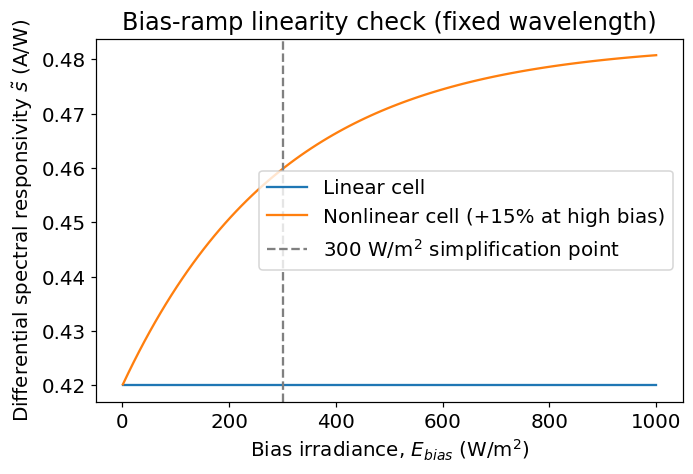

In [9]:
E_bias = np.linspace(1, 1000, 100)
s_stc = 0.42  # A/W, arbitrary reference value at this wavelength

s_linear = eh.bias_ramp_dsr(E_bias, s_stc, nonlinearity=0.0)
s_nonlinear = eh.bias_ramp_dsr(E_bias, s_stc, nonlinearity=0.15)

plt.figure(figsize=(6.5, 4.5))
plt.plot(E_bias, s_linear, label='Linear cell')
plt.plot(E_bias, s_nonlinear, label='Nonlinear cell (+15% at high bias)')
plt.axvline(300, ls='--', color='gray', label='300 W/m$^2$ simplification point')
plt.xlabel(r'Bias irradiance, $E_{bias}$ (W/m$^2$)')
plt.ylabel(r'Differential spectral responsivity $\tilde s$ (A/W)')
plt.legend(); plt.title('Bias-ramp linearity check (fixed wavelength)')
plt.tight_layout(); plt.show()

## Assumptions and limitations

The models used in this notebook **assume**:
- one-dimensional carrier transport (no lateral spreading),
- spatially uniform doping and constant $D$, $L$, $S$,
- a simplified analytic reflectance model (no thin-film interference / ray
  tracing), and a coarse interpolation of $\alpha(\lambda)$,
- an analytic approximation of the AM1.5G spectrum, not the tabulated
  IEC 60904-3 reference data,
- no series-resistance or nonlinear recombination effects beyond the toy
  bias-ramp model.

For quantitative work, replace `eqe_helper.alpha_silicon` and
`eqe_helper.am15g_simplified` with tabulated reference data (e.g. Green
(2008), Schinke et al. (2015), IEC 60904-3), and use device simulation
(e.g. Quokka3, Sentaurus, PC1D) for accurate optical and electrical
modelling.

## References

1. C. Schinke, S. Schädlich, T. Gewohn, D. Hinken, *Analysis of the Quantum
   Efficiency of Silicon Solar Cells* (lab manual), Leibniz Universität
   Hannover / ISFH, 2019.
2. K. Bothe, D. Hinken, B. Min, C. Schinke, "Accuracy of Simplifications
   for Spectral Responsivity Measurements of Solar Cells," *IEEE J.
   Photovolt.* 8(2), 611-620, 2018.
3. Quokka3 Modelling Guide — optical modelling (T_ext-Z model,
   EQE = T_ext × IQE).
4. IEC 60904-8, *International Standard: Photovoltaic devices — Part 8:
   Measurement of spectral responsivity of a photovoltaic (PV) device*.